# [Practice] Linear Regression

### [Contents]  
- EDA   
- 선형 회귀 Baseline Modeling  
- 잔차진단 (Residual Diagnostics)  

### [Task]
1. Baseline Model의 회귀분석 결과를 자신의 언어로 해석해 보세요.
   - EDA, 잔차 분석결과 함께 해석
2. 선형회귀모델의 성과를 개선해 보세요.
   - Hint: 곡선 패턴을 보인 변수는 무엇인가? 어떻게 선형화 할 것인가?  
   - 개선 전후 비교
3. 유의하지 않은 변수를 제거하고 효과를 살펴보세요.
   - 통계적 유의성(statistical significance) vs 효과크기(effect size) 관점에서 살펴보기
   

### [Data]  
Real Estate Valuation Data set  
https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set


### [Note]  
회귀분석 개념에 집중할 수 있는 전처리를 최소화 데이터셋 활용  

### Data Load

In [1]:
#  UCI Machine Learning Data Load Library
!pip install ucimlrepo

zsh:1: command not found: pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.nonparametric.smoothers_lowess import lowess
from ucimlrepo import fetch_ucirepo

In [3]:
## 데이터 로드
real_estate = fetch_ucirepo(id=477)
X = real_estate.data.features
y = real_estate.data.targets

df = pd.concat([X, y], axis=1)
df.columns = ['transaction_date', 'house_age', 'dist_to_mrt', 'n_convenience', 'latitude', 'longitude', 'price']
features = ['transaction_date', 'house_age', 'dist_to_mrt', 'n_convenience', 'latitude', 'longitude']

print(f"Data Shape: {df.shape}")
print(df.isnull().sum())

Data Shape: (414, 7)
transaction_date    0
house_age           0
dist_to_mrt         0
n_convenience       0
latitude            0
longitude           0
price               0
dtype: int64


### EDA

In [4]:
## 기술통계량

print(df.describe())

       transaction_date   house_age  dist_to_mrt  n_convenience    latitude  \
count        414.000000  414.000000   414.000000     414.000000  414.000000   
mean        2013.148971   17.712560  1083.885689       4.094203   24.969030   
std            0.281967   11.392485  1262.109595       2.945562    0.012410   
min         2012.667000    0.000000    23.382840       0.000000   24.932070   
25%         2012.917000    9.025000   289.324800       1.000000   24.963000   
50%         2013.167000   16.100000   492.231300       4.000000   24.971100   
75%         2013.417000   28.150000  1454.279000       6.000000   24.977455   
max         2013.583000   43.800000  6488.021000      10.000000   25.014590   

        longitude       price  
count  414.000000  414.000000  
mean   121.533361   37.980193  
std      0.015347   13.606488  
min    121.473530    7.600000  
25%    121.528085   27.700000  
50%    121.538630   38.450000  
75%    121.543305   46.600000  
max    121.566270  117.500000  


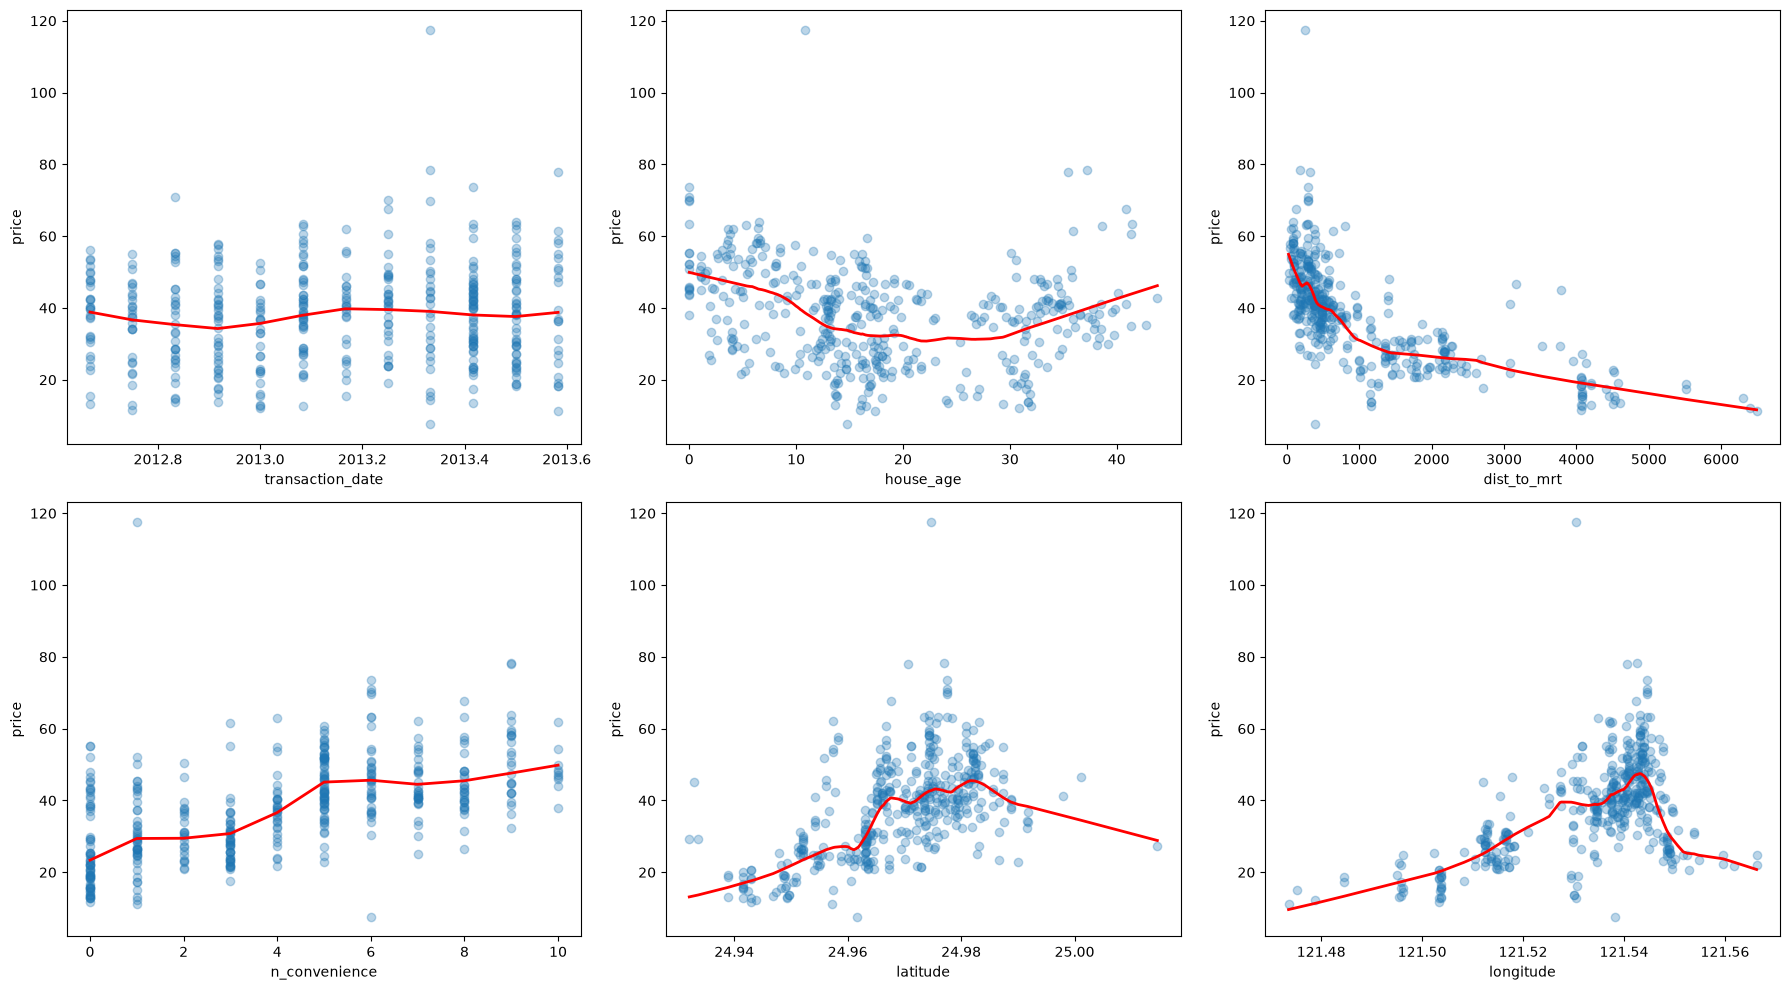

In [5]:
## 산점도 (변수 vs price) + LOESS

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(features):
    ax = axes[i // 3, i % 3]
    ax.scatter(df[col], df['price'], alpha=0.3)
    smoothed = lowess(df['price'], df[col], frac=0.3)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='red', linewidth=2)
    ax.set_xlabel(col); ax.set_ylabel('price')
plt.tight_layout(); plt.show()

In [6]:
## 상관분석

print(df.corr(numeric_only=True)['price'].sort_values(ascending=False))

price               1.000000
n_convenience       0.571005
latitude            0.546307
longitude           0.523287
transaction_date    0.087491
house_age          -0.210567
dist_to_mrt        -0.673613
Name: price, dtype: float64


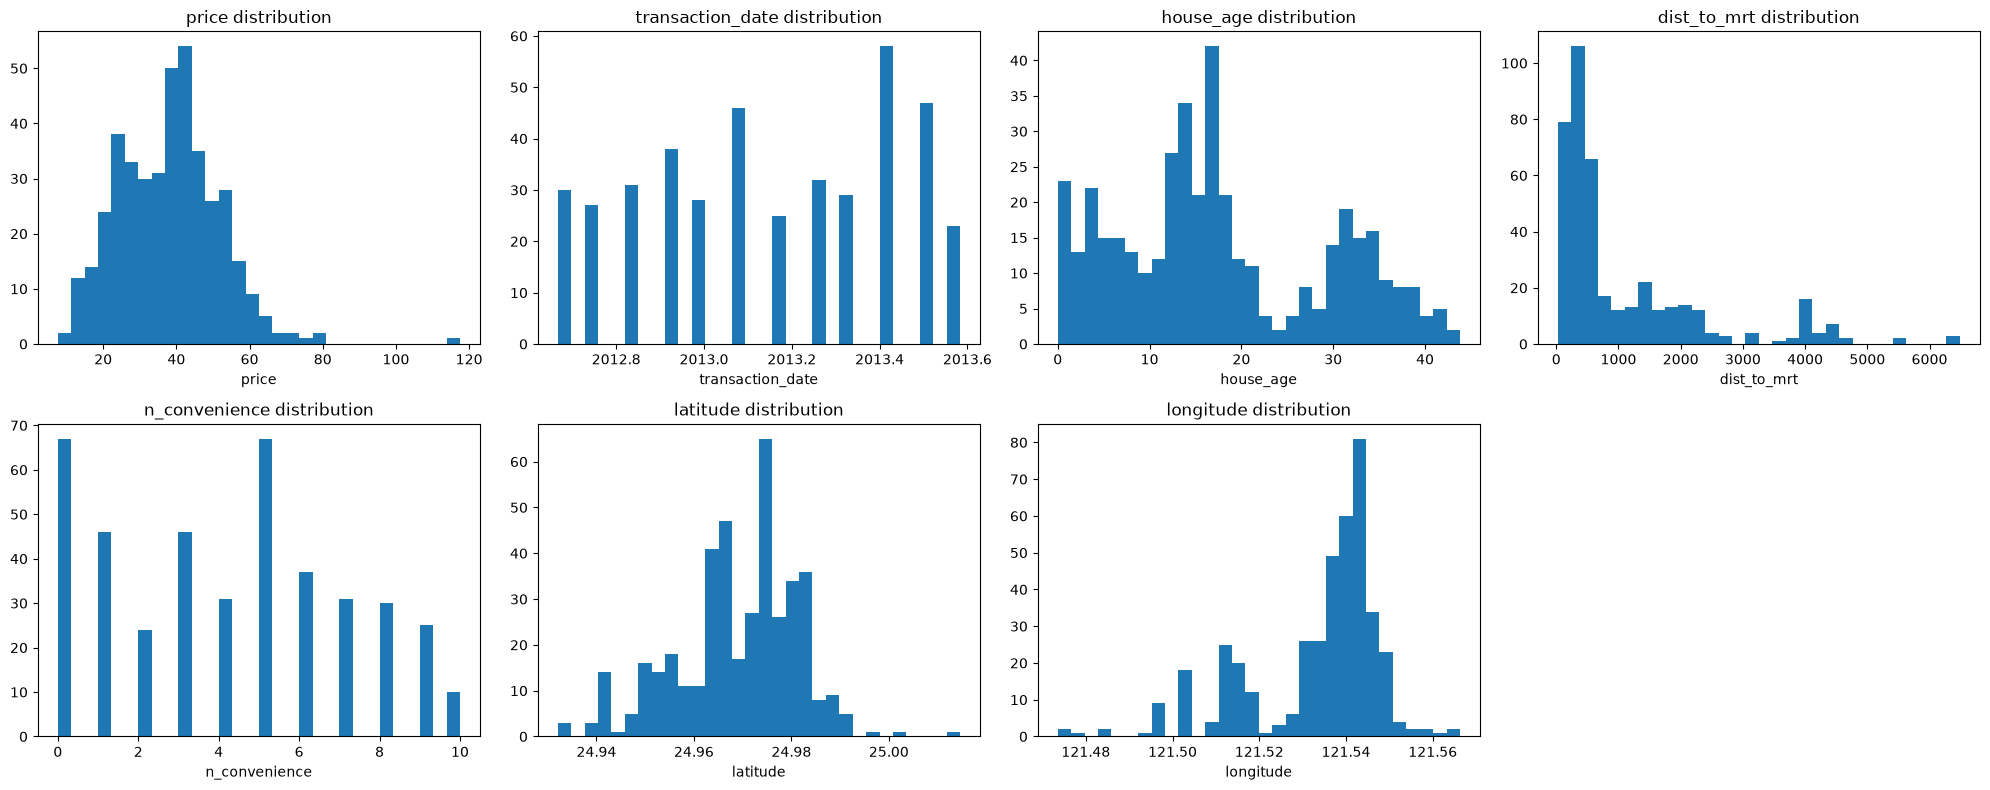

[Skewness]
dist_to_mrt         1.888757
longitude          -1.219591
price               0.599853
latitude           -0.438598
house_age           0.382926
n_convenience       0.154607
transaction_date   -0.150572
dtype: float64


In [7]:
## 분포 확인

all_cols = ['price'] + features

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, col in enumerate(all_cols):
    ax = axes[i // 4, i % 4]
    ax.hist(df[col], bins=30)
    ax.set_xlabel(col); ax.set_title(f'{col} distribution')
axes[1, 3].axis('off')
plt.tight_layout(); plt.show()

print("[Skewness]")
print(df[all_cols].skew().sort_values(key=abs, ascending=False))

### Baseline

In [8]:
## 베이스라인 분석

X_train, X_test, y_train, y_test = train_test_split(df[features], df['price'], test_size=0.2, random_state=42)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

baseline_model = sm.OLS(y_train, X_train_sm.astype(float)).fit()
print(baseline_model.summary())

baseline_train_pred = baseline_model.predict(X_train_sm)
baseline_test_pred = baseline_model.predict(X_test_sm)

baseline_train_rmse = mean_squared_error(y_train, baseline_train_pred) ** 0.5
baseline_test_rmse = mean_squared_error(y_test, baseline_test_pred) ** 0.5

print(f"\n=== 성능 ===")
print(f"Train RMSE: {baseline_train_rmse:.4f}")
print(f"Test RMSE: {baseline_test_rmse:.4f}")
print(f"Test-Train RMSE 차이: {baseline_test_rmse - baseline_train_rmse:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.558
Model:                            OLS   Adj. R-squared:                  0.550
Method:                 Least Squares   F-statistic:                     68.21
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           1.46e-54
Time:                        15:56:54   Log-Likelihood:                -1201.2
No. Observations:                 331   AIC:                             2416.
Df Residuals:                     324   BIC:                             2443.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.304e+04   7814.949  


=== 성능 ===
Train RMSE: 9.1167
Test RMSE: 7.3148
Test-Train RMSE 차이: -1.8019


### 잔차진단 (Residual Diagnostics)

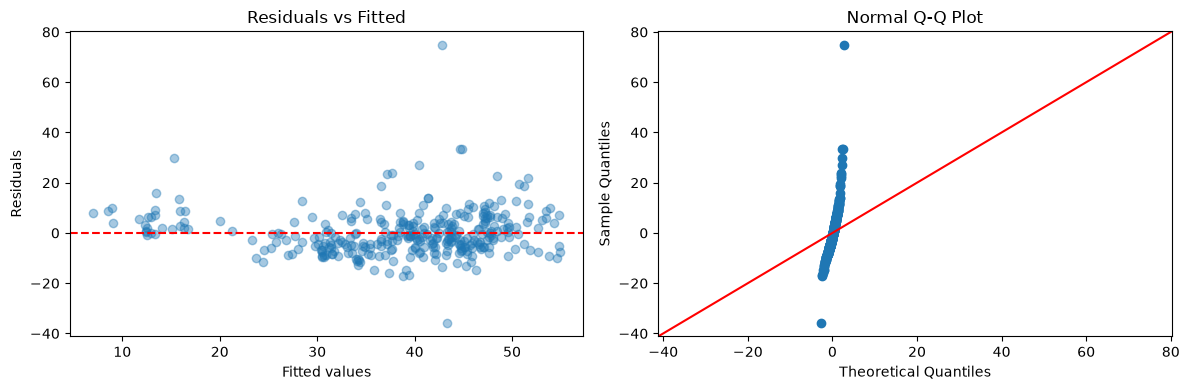

Breusch-Pagan p-value: 0.2089  (0.05 미만이면 이분산성 문제)


In [9]:
## 잔차진단 (Residual Diagnostics)

baseline_resid = baseline_model.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(baseline_train_pred, baseline_resid, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

sm.qqplot(baseline_resid, line='45', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot')

plt.tight_layout(); plt.show()

bp_pvalue = het_breuschpagan(baseline_resid, X_train_sm)[1]
print(f"Breusch-Pagan p-value: {bp_pvalue:.4f}  (0.05 미만이면 이분산성 문제)")

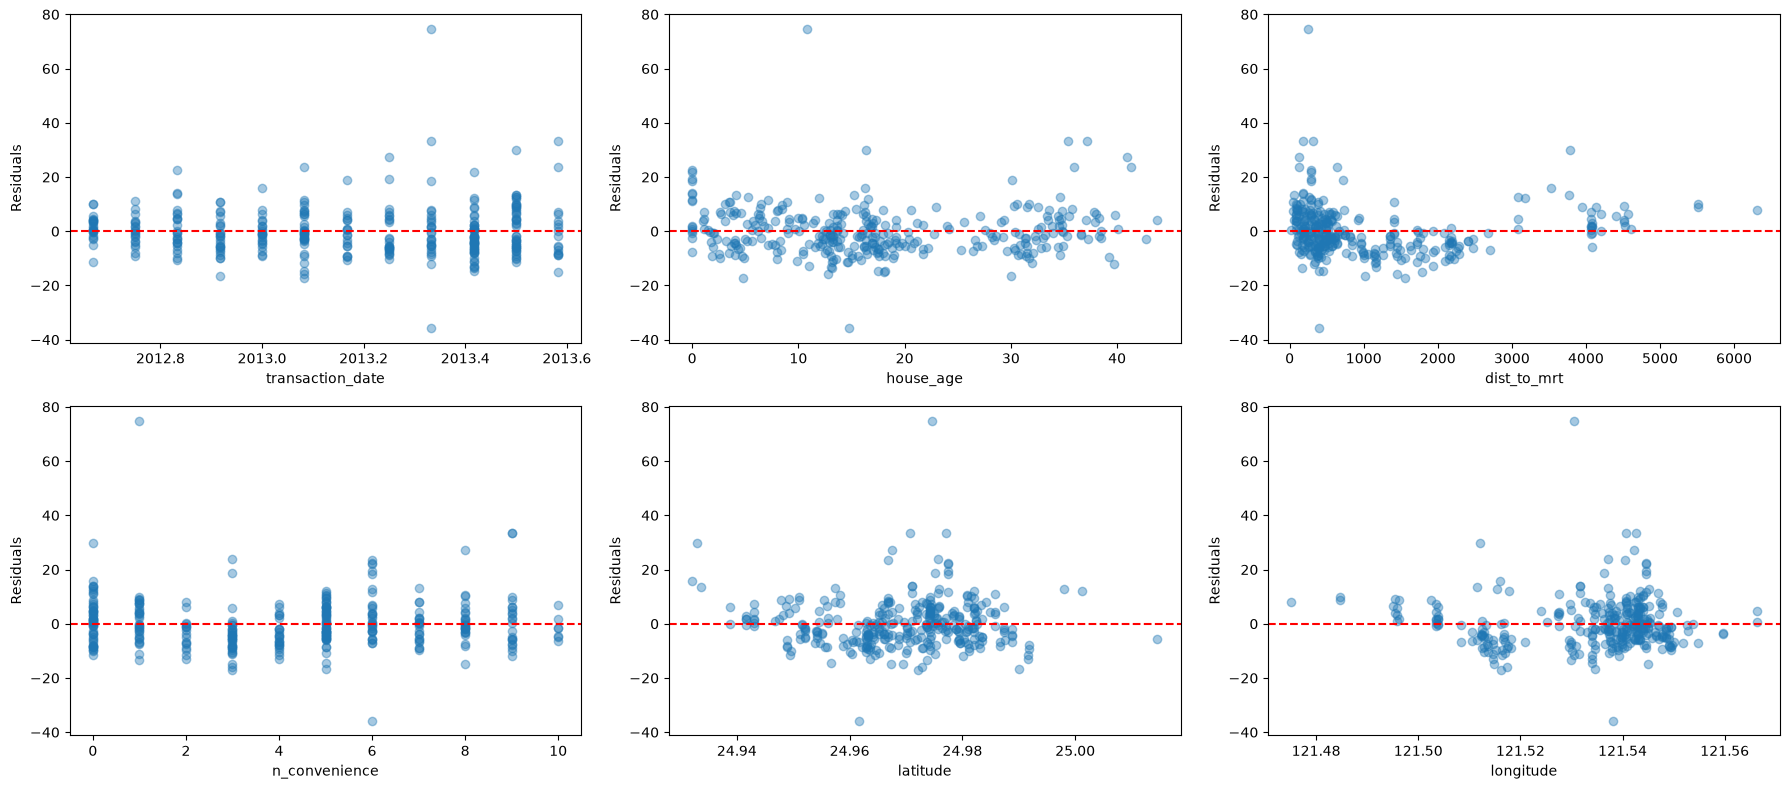

In [10]:
## 변수별 잔차 패턴 확인

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i, col in enumerate(features):
    ax = axes[i // 3, i % 3]
    ax.scatter(X_train[col], baseline_resid, alpha=0.4)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_xlabel(col); ax.set_ylabel('Residuals')
plt.tight_layout(); plt.show()

### Task 1. Baseline Model의 회귀분석 결과를 해석해 보세요.

- EDA, 잔자분석 내용도 함께 고려하여 해석하세요.

### Task 2. Baseline 모델을 개선해 보세요.

- Hint: 잔차에 패턴을 만든 변수를 변환해 보세요. (ex: 로그)
  - 아래 코드의 log_features 기본값은 예시 임
  - 이 변수가 최선의 선택인지, EDA(산점도+LOESS, 잔차 vs 변수 그래프, skewness)를 다시 보고 직접 판단한 뒤 값을 바꿔보세요.

- 전후 결과를 비교해 보세요.


In [11]:
## 로그변환 개선 예시

# Task. 잔차에 패턴을 만든 변수를 선택해서 로그변환 해보세요. (여러 개 선택 가능)
# 최선의 선택인지 검증하고 수정해보세요.
log_features = ['dist_to_mrt']   # skew 1.89(최대) + log_gain 안정적 → 로그변환의 전형적 대상(거리 변수)

df_log = df.copy()
for col in log_features:
    # 0에 가까운 값이 있는 변수도 있으니, log1p(=log(1+x))를 활용해 변환
    df_log[col] = np.log1p(df_log[col])

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    df_log[features], df_log['price'], test_size=0.2, random_state=42
)

X_train_log_sm = sm.add_constant(X_train_log)
log_model = sm.OLS(y_train_log, X_train_log_sm.astype(float)).fit()
print(log_model.summary())

log_train_pred = log_model.predict(X_train_log_sm)
log_resid = log_model.resid

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.627
Method:                 Least Squares   F-statistic:                     93.50
Date:                Tue, 28 Jul 2026   Prob (F-statistic):           1.09e-67
Time:                        15:56:54   Log-Likelihood:                -1170.1
No. Observations:                 331   AIC:                             2354.
Df Residuals:                     324   BIC:                             2381.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.902e+04   5852.880  

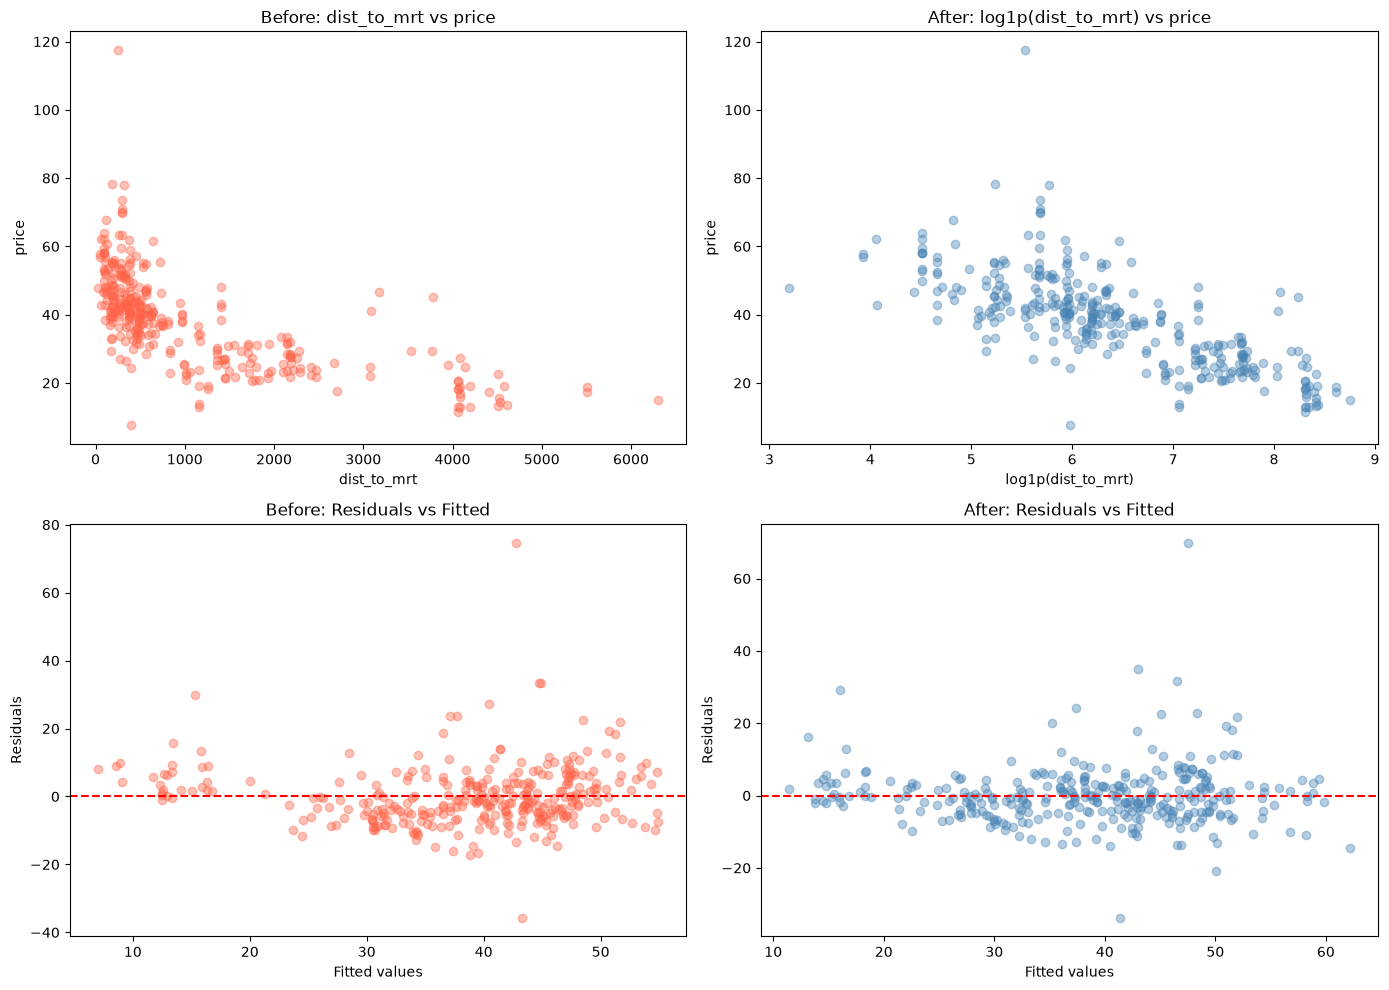

                      지표    Before  After(로그변환)
0                     R²  0.558120     0.633901
1            Adjusted R²  0.549937     0.627121
2             Train RMSE  9.116660     8.298182
3              Test RMSE  7.314754     6.779423
4     Test-Train RMSE 차이 -1.801906    -1.518759
5  Breusch-Pagan p-value  0.208906     0.131099


In [12]:
## Before / After 비교

X_test_log_sm = sm.add_constant(X_test_log)
log_test_pred = log_model.predict(X_test_log_sm)

log_train_rmse = mean_squared_error(y_train_log, log_train_pred) ** 0.5
log_test_rmse = mean_squared_error(y_test_log, log_test_pred) ** 0.5

plot_var = log_features[0]   # 비교 시각화에 사용할 변수 (선택한 변수 중 첫 번째)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(X_train[plot_var], y_train, alpha=0.4, color='tomato')
axes[0,0].set_xlabel(plot_var); axes[0,0].set_ylabel('price')
axes[0,0].set_title(f'Before: {plot_var} vs price')

axes[0,1].scatter(X_train_log[plot_var], y_train_log, alpha=0.4, color='steelblue')
axes[0,1].set_xlabel(f'log1p({plot_var})'); axes[0,1].set_ylabel('price')
axes[0,1].set_title(f'After: log1p({plot_var}) vs price')

axes[1,0].scatter(baseline_train_pred, baseline_resid, alpha=0.4, color='tomato')
axes[1,0].axhline(0, color='red', linestyle='--')
axes[1,0].set_xlabel('Fitted values'); axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title('Before: Residuals vs Fitted')

axes[1,1].scatter(log_train_pred, log_resid, alpha=0.4, color='steelblue')
axes[1,1].axhline(0, color='red', linestyle='--')
axes[1,1].set_xlabel('Fitted values'); axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('After: Residuals vs Fitted')

plt.tight_layout(); plt.show()

bp_after = het_breuschpagan(log_resid, X_train_log_sm)[1]

comparison = pd.DataFrame({
    '지표': ['R²', 'Adjusted R²', 'Train RMSE', 'Test RMSE', 'Test-Train RMSE 차이', 'Breusch-Pagan p-value'],
    'Before': [baseline_model.rsquared, baseline_model.rsquared_adj,
               baseline_train_rmse, baseline_test_rmse,
               baseline_test_rmse - baseline_train_rmse, bp_pvalue],
    'After(로그변환)': [log_model.rsquared, log_model.rsquared_adj,
                     log_train_rmse, log_test_rmse,
                     log_test_rmse - log_train_rmse, bp_after]
})
print(comparison)

### 비선형성은 어떻게 확인할까? (Optionnal)  
  - skew와 비선형성은 같은 이야기일까? 아래 결과로 살펴보세요.

In [13]:
## Skewness vs 비선형성 지표 비교 (2차항 기반 / 로그변환 기반)
from sklearn.linear_model import LinearRegression

results = {}
for col in features:
    y_true = df['price'].values
    x_raw = df[[col]].values

    # 1) 선형 모델 (기준선)
    r2_linear = LinearRegression().fit(x_raw, y_true).score(x_raw, y_true)

    # 2) 2차항 추가 모델 → U자형/언덕형(비단조) 곡률 감지
    x_quad = np.column_stack([x_raw, x_raw**2])
    r2_quad = LinearRegression().fit(x_quad, y_true).score(x_quad, y_true)

    # 3) 로그변환 모델 → 단조 감쇠/증가형 곡률 감지
    x_log = np.log1p(df[[col]] - df[col].min()).values
    r2_log = LinearRegression().fit(x_log, y_true).score(x_log, y_true)

    results[col] = {
        'skew': df[col].skew(),
        'R2_linear': r2_linear,
        'R2_quad': r2_quad,
        'quad_gain': r2_quad - r2_linear,      # 2차항을 추가했을 때 R² 증가분
        'R2_log': r2_log,
        'log_gain': r2_log - r2_linear,        # 로그변환했을 때 R² 증가분
    }

res_df = pd.DataFrame(results).T

print("-- skew 기준 정렬 (변수 자체의 치우침) --")
print(res_df.sort_values('skew', key=abs, ascending=False).round(4))

print("\n-- quad_gain 기준 정렬 (price와의 비선형성, U자/언덕형 포함) --")
print(res_df.sort_values('quad_gain', ascending=False).round(4))

print("\n-- log_gain 기준 정렬 (로그변환으로 교정되는 정도) --")
print(res_df.sort_values('log_gain', ascending=False).round(4))

-- skew 기준 정렬 (변수 자체의 치우침) --
                    skew  R2_linear  R2_quad  quad_gain  R2_log  log_gain
dist_to_mrt       1.8888     0.4538   0.5270     0.0732  0.4977    0.0440
longitude        -1.2196     0.2738   0.2738    -0.0000  0.2759    0.0020
latitude         -0.4386     0.2985   0.3348     0.0364  0.3002    0.0017
house_age         0.3829     0.0443   0.2015     0.1572  0.1107    0.0664
n_convenience     0.1546     0.3260   0.3302     0.0041  0.3068   -0.0192
transaction_date -0.1506     0.0077   0.0077    -0.0000  0.0075   -0.0002

-- quad_gain 기준 정렬 (price와의 비선형성, U자/언덕형 포함) --
                    skew  R2_linear  R2_quad  quad_gain  R2_log  log_gain
house_age         0.3829     0.0443   0.2015     0.1572  0.1107    0.0664
dist_to_mrt       1.8888     0.4538   0.5270     0.0732  0.4977    0.0440
latitude         -0.4386     0.2985   0.3348     0.0364  0.3002    0.0017
n_convenience     0.1546     0.3260   0.3302     0.0041  0.3068   -0.0192
transaction_date -0.1506     0.00

### Task 3. 유의하지 않은 변수 제거해보세요.
 - Statistical significance vs Effect size 를 생각해보세요

In [14]:
## 유의하지 않은 변수 제거

# model.summary()에서 p-value가 가장 큰 변수는?
# 유의하지 않은 변수를 제거하고 재적합한 뒤, 성능이 얼마나 달라지는지 확인하기
drop_features = ['longitude']   # p-value 0.762 로 유일하게 유의하지 않은 변수

reduced_features = [f for f in features if f not in drop_features]
X_train_reduced_sm = sm.add_constant(X_train_log[reduced_features])
reduced_model = sm.OLS(y_train_log, X_train_reduced_sm.astype(float)).fit()

print(f"변수 {len(features)}개 -> {len(reduced_features)}개")
print(f"Adjusted R²: {log_model.rsquared_adj:.4f} -> {reduced_model.rsquared_adj:.4f}")

변수 6개 -> 5개
Adjusted R²: 0.6271 -> 0.6282


###